In [35]:
import sys
import os
import argparse
import time
from treeswift import *
import treeswift
import json
import numpy as np
import tskit
import random
import matplotlib.pyplot as plt
import multiple_tree_matching

def normalize_tree(tree):
	height = tree.height()
	for n in tree.traverse_preorder():
		if n.edge_length:
			n.edge_length /= height

def __label_tree__(tree_obj):
	is_labeled = True
	i = 0
	labels = set()
	for node in tree_obj.traverse_preorder():
		if not node.is_root():
			if not node.edge_length:
				node.edge_length = 0
		if node.is_leaf():
			continue
		if not node.label or node.label in labels or node.label[0] != 'I': 
			is_labeled = False
			node.label = 'I' + str(i)
			i += 1        
		labels.add(node.label)
	return is_labeled


def hmean(vals):
	y = [1/x for x in vals]
	return len(y) / np.sum(y)

def log_mean(vals):
	return np.exp(np.mean(np.log(vals)))

def compare_trees_pairwise_distances(tree1, tree2):
	# print(tree1, tree2)
	tree1_obj = read_tree_newick(tree1)
	tree2_obj = read_tree_newick(tree2)

	# normalize_tree(tree1_obj)
	# normalize_tree(tree2_obj)

	# print(tree1_obj.newick(), tree2_obj.newick())

	tree1_size = len([n.label for n in tree1_obj.traverse_leaves()])
	tree2_size = len([n.label for n in tree2_obj.traverse_leaves()])

	if tree1_size != tree2_size:
		print("Trees not the same size")
		return

	leaves = [n.label for n in tree2_obj.traverse_leaves()]

	dist_1 = tree1_obj.distance_matrix(leaf_labels=True)
	dist_2 = tree2_obj.distance_matrix(leaf_labels=True)

	MSE = 0
	for i in range(len(leaves)):
		for j in range(i+1,len(leaves)):
			l1 = leaves[i]
			l2 = leaves[j]
			MSE += (dist_1[l1][l2] - dist_2[l1][l2])**2

	total = len(leaves) * (len(leaves) - 1)/2
	return MSE/total

def lower_node_rate_map(tree: tskit.Tree, rates, dropped_index):
    index = -1
    node_to_rate = {}
    current = 0
    assert len(rates) + len(dropped_index) == 2 * (tree.num_samples())-1
    for nd in list(tree.nodes(order="postorder"))[0:]:
        index += 1
        if index in dropped_index:
            node_to_rate[nd] = None
        else:
            node_to_rate[nd] = rates[current]
            current += 1
    return node_to_rate


def compare_trees_TCMM(tree1:tskit.Tree, tree2:tskit.Tree, method = 'mean'):
	tree1_obj = read_tree_newick(tree1.as_newick())
	tree2_obj = read_tree_newick(tree2.as_newick())

	# normalize_tree(tree1_obj)
	# normalize_tree(tree2_obj)

	__label_tree__(tree1_obj)
	__label_tree__(tree2_obj)

	leaves = [n.label for n in tree1_obj.traverse_leaves()]

	new_tree, obj, rates, bls,dropped_index = multiple_tree_matching.compute_optimal_rates(tree1_obj, tree2_obj, r = 0)
	# print(dropped_index)
	# print(obj)
	rates = [float(r) for r in rates]

	node_to_rate=lower_node_rate_map(tree1,rates,dropped_index)

	return rates,node_to_rate

	if method == 'mean':
		return np.mean(rates) - 1 + np.std(rates)
	if method == 'hmean':
		return hmean(rates) - 1 + np.std(rates)
	if method == 'log_mean':
		return log_mean(rates) + np.std(rates)
	# print(norm_rates)
	# print(np.mean(norm_rates), np.std(norm_rates))
	# return obj
	# dist = log_mean(norm_rates) + np.std(norm_rates)
	# dist = np.mean(norm_rates) + np.std(norm_rates)
	return dist

In [2]:
def rates_mean(combined_rates,method):
    if method=="mean":
        return np.mean(combined_rates[-1])
    if method=="hmean":
        return hmean(combined_rates[-1])
    if method=="log_mean":
        return log_mean(combined_rates[-1])

In [36]:
true_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/Ne2e+04_r1e-08_100_1e+06_0.trees")
inferred_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/singer_inferred/Ne2e+04_r1e-08_100_1e+06_49.trees")

In [37]:
true_arg

In [5]:
tree1=inferred_arg.at(1e4, sample_lists=True)
tree1_obj=read_tree_newick(tree1.as_newick())
__label_tree__(tree1_obj)
l=list(tree1_obj.traverse_preorder())
for n in tree1_obj.traverse_preorder():
    print(n)

I0
I1
I2
I3
I4
I5
n12
n10
I6
I7
n55
n41
I8
n9
n2
I9
I10
I11
n73
n37
n19
n66
I12
I13
I14
n53
I15
I16
I17
n79
n8
n85
n20
I18
I19
I20
I21
n28
n77
I22
I23
I24
I25
n84
n49
n86
n60
I26
n70
n67
I27
I28
n91
n44
I29
I30
n61
n23
I31
n30
n15
I32
I33
I34
I35
I36
n98
n96
n38
I37
I38
n89
n78
n72
I39
I40
I41
n93
n83
n48
n92
I42
I43
n26
I44
I45
I46
I47
I48
n74
n13
n65
n50
I49
n27
I50
I51
n76
n29
n75
I52
I53
I54
I55
I56
n46
n11
n82
n17
n42
n39
I57
I58
n64
n18
n88
I59
I60
I61
I62
I63
I64
n69
n58
n63
n40
n45
I65
I66
I67
n68
n31
n54
n90
I68
n80
n21
I69
n71
n25
I70
I71
I72
n62
n16
I73
I74
I75
I76
I77
I78
n51
n36
n81
I79
I80
n24
n14
n34
I81
I82
I83
I84
n94
n5
n32
n4
n22
I85
I86
n43
n6
I87
n97
n7
I88
n33
n1
I89
I90
I91
I92
n95
n35
n87
I93
I94
n52
n0
n99
I95
I96
I97
I98
n59
n3
n57
n47
n56


In [6]:
seq_length = true_arg.sequence_length
n = 100

all_dists = []
all_random = []

all_rates=[]
all_trees_maps=[]

for i in range(n):
    pos = int(seq_length / n * i)
    t_tree = true_arg.at(pos, sample_lists=True)
    i_tree = inferred_arg.at(pos, sample_lists=True)

    if (t_tree.num_roots>1 or i_tree.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(t_tree, i_tree)
        all_rates.append([pos, 'rates', rates])
        all_trees_maps.append([t_tree,i_tree,node_to_rate])

    # random_pos = random.randint(1, int(seq_length))
    # r_tree = inferred_arg.at(random_pos, sample_lists=True)

    # if (t_tree.num_roots>1 or r_tree.num_roots>1):
    #     print("trees have multiple roots")
    #     continue

    # else:
    #     random_dist = compare_trees_TCMM(t_tree.as_newick(), r_tree.as_newick())
    #     all_random.append([pos, random_pos, 'mean', random_dist[0]])
    #     all_random.append([pos, random_pos, 'hmean', random_dist[1]])
    #     all_random.append([pos, random_pos, 'log_mean', random_dist[2]])
    # if args.method == 'kc':
    # 	random_dist = t_tree.kc_distance(r_tree)
    # else:
    # 	random_dist = compare_trees_TCMM(t_tree.as_newick(), r_tree.as_newick(), args.method)
    # print(dist, random_dist)
    # all_random.append([pos, random_pos, random_dist])


/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


In [36]:
tree=all_trees_maps[20][0]
i_tree=all_trees_maps[20][1]
node_rate=all_trees_maps[20][2]
ids=list(tree.nodes(order="timeasc"))

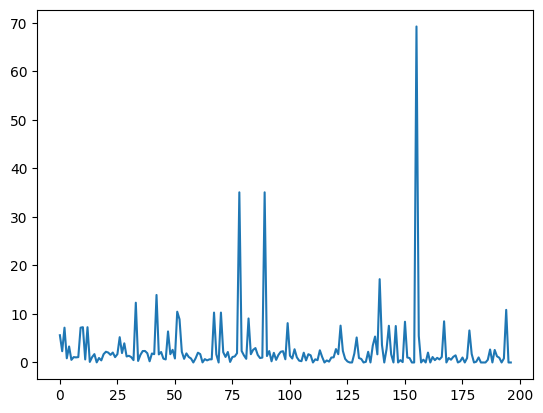

In [37]:
plt.plot(np.array([node_rate[i] for i in ids]))

In [7]:
sorted_items = sorted(
    node_to_rate.items(),
    key=lambda x: float('-inf') if x[1] is None else x[1]
)

In [8]:
sorted_items

[(2410, None),
 (767, -1.7527924422863965e-06),
 (777, -1.0633937949666802e-06),
 (180, -1.035376122926831e-06),
 (795, -9.475071750159611e-07),
 (207, -4.308716840254231e-07),
 (756, -3.687708308926204e-07),
 (523, -3.368537116468947e-07),
 (582, -1.591304031661456e-07),
 (1255, -1.0765838215855597e-07),
 (940, -7.720971508755408e-08),
 (780, -5.649725422686482e-08),
 (848, -3.579395471769869e-08),
 (605, -2.844449516343505e-08),
 (191, -7.815262906278263e-09),
 (675, -4.538104411580557e-09),
 (1332, 1.1426442875056455e-09),
 (846, 1.700227751719977e-08),
 (871, 1.7274815245656692e-08),
 (367, 2.0973728926018944e-08),
 (1006, 1.450354345817292e-07),
 (546, 4.662272414897855e-07),
 (214, 4.7033394288336104e-07),
 (84, 2.0420437048060554e-06),
 (46, 2.042043707591803e-06),
 (632, 3.5217048192267883e-06),
 (3, 1.1034978898677317e-05),
 (59, 1.1034979068178327e-05),
 (1178, 0.01408985097861035),
 (14, 0.08927320766619526),
 (24, 0.08927320766621001),
 (18, 0.10209305571894259),
 (72, 0.12

In [14]:
tree1 = true_arg.at(10000, sample_lists=True)
tree2 = true_arg.at(11000, sample_lists=True)

In [28]:
tree1 = true_arg.at(10000, sample_lists=True)
rs=[]
kc=[]
rf=[]
for i in range(100):
    tree2=true_arg.at(10000+i*1000, sample_lists=True)
    rs.append(compare_trees_TCMM(tree1.as_newick(),tree2.as_newick()))
    kc.append(tree1.kc_distance(tree2))
    rf.append(tree1.rf_distance(tree2))

/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/var/folders/kz/82_zg7j94hs8p268qx2hvkg80000gn/T/ipykernel_12620/2081209516.py:43: RuntimeWarning: invalid value encountered in log
  return np.exp(np.mean(np.log(vals)))


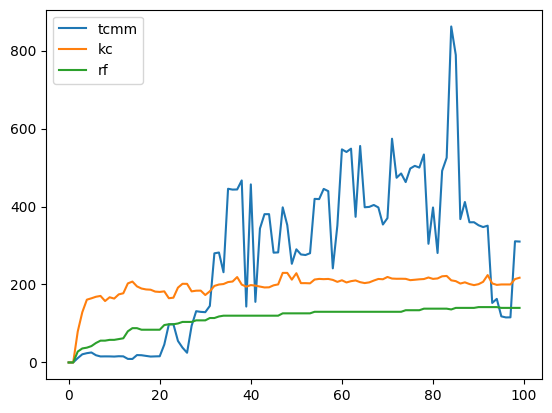

In [34]:
plt.plot([l[0] for l in rs],label="tcmm")
plt.plot(kc,label="kc")
plt.plot(rf,label="rf")
plt.legend()

In [9]:
t1=true_arg.at_index(0)
t2=true_arg.at_index(1)

rs,nrs=compare_trees_TCMM(t1,t2)

In [10]:
rates_values = [nrs[k] for k in sorted(nrs)]


/var/folders/kz/82_zg7j94hs8p268qx2hvkg80000gn/T/ipykernel_61176/1257052396.py:3: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(np.array(numeric_rates_values)))


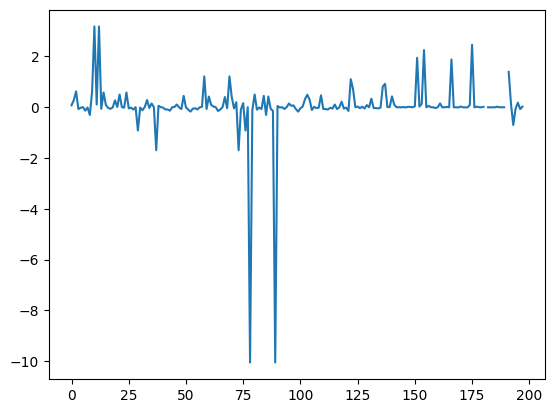

In [11]:
numeric_rates_values = [value for value in rates_values if isinstance(value, (int, float))]

plt.plot(np.log(np.array(numeric_rates_values)))

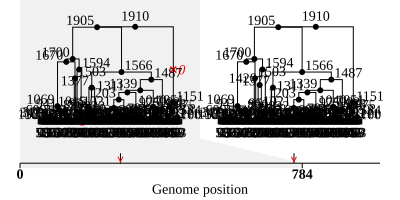

In [12]:
display(true_arg.draw_svg(x_lim=[0,1000]))

In [13]:
def print_node_info(tree:tskit.Tree,nd):
    print("children:",tree.children(nd))
    print("parent:",tree.parent(nd))
    print("number of leaves:",tree.get_num_leaves(nd))

In [14]:
print_node_info(t1,103)

children: (78, 89)
parent: 144
number of leaves: 2


In [68]:
nrs[1015]

-8.734318389857643e-07

In [ ]:
for k, v in sorted(nrs.items(), key=lambda x: (x[1] is None, x[1])):
    print(k, v)


1377 -1.738871756686689e-06
1015 -8.734318389857643e-07
78 4.3226389434897276e-05
89 4.3226389614646585e-05
37 0.1841155191024923
73 0.18411551910249707
76 0.39979309982783623
29 0.39979309982789674
1566 0.49797562668284684
8 0.738472395927363
85 0.7384723959273709
99 0.8422141143412006
52 0.8422141143412304
64 0.8639149442462818
88 0.8639149442462829
153 0.8656080937263825
43 0.8745413444949238
6 0.8745413444949269
31 0.8901315652313339
106 0.8993942019272577
79 0.9016406810978931
51 0.9097350944354005
81 0.909735094435402
128 0.9138255008430219
27 0.9144290994280805
74 0.9144290994280828
55 0.9164116268388328
41 0.9164116268388334
65 0.9166265449402393
42 0.9166265449402419
48 0.9312961083339469
83 0.9312961083339532
140 0.9318415002969539
1700 0.9320029221656558
3 0.9327991643549419
59 0.9327991643549881
120 0.9333013506925473
98 0.9333633627377559
93 0.9333633627377568
123 0.9336467603351065
17 0.9391554243367342
13 0.9391554243367409
1594 0.9450680761192135
143 0.946934250530052
5

In [15]:
def get_all_sets(tree:tskit.Tree):
    sets=[]
    for i in tree.nodes():
        if tree.is_sample(i):
            pass
        else:
            sets.append(set(tree.leaves(i)))
    return sets
def branch_rf(tree1:tskit.Tree,tree2:tskit.Tree):
    #branch_rf with give a value for each branch in tree1, where the value is the maximal correlation of the samples being covered for focal branch and any branch in tree2
    sets2=get_all_sets(tree2)
    nds={}
    for nd in tree1.nodes():
        if tree1.is_root(nd):
            nds[nd] = None
            continue
        if (tree1.is_sample(nd)):
            nds[nd]=1
            continue

        s = set(tree1.leaves(nd))

        best_val = -1
        best_s2 = None

        for s2 in sets2:
            inter = len(s & s2)
            denom = max(len(s), len(s2))
            val = inter / denom if denom > 0 else 0

            if val > best_val:
                best_val = val
                best_s2 = s2
        nds[nd]=best_val
    return nds


In [16]:
nrs2=branch_rf(t1,t2)

In [17]:
for k, v in sorted(nrs2.items(), key=lambda x: (x[1] is None, x[1])):
    print(k, v)


1015 0.5714285714285714
1377 0.6666666666666666
1594 0.8
1700 0.9117647058823529
1566 0.9482758620689655
1151 1.0
584 1.0
63 1
416 1.0
40 1
211 1.0
45 1
100 1.0
58 1
69 1
1040 1.0
638 1.0
114 1.0
2 1
9 1
633 1.0
41 1
55 1
875 1.0
25 1
71 1
1905 1.0
105 1.0
10 1
12 1
430 1.0
19 1
260 1.0
37 1
73 1
890 1.0
20 1
172 1.0
79 1
158 1.0
8 1
85 1
1487 1.0
928 1.0
66 1
322 1.0
18 1
281 1.0
64 1
88 1
1339 1.0
1051 1.0
455 1.0
262 1.0
36 1
258 1.0
34 1
106 1.0
14 1
24 1
449 1.0
51 1
81 1
982 1.0
537 1.0
38 1
96 1
658 1.0
28 1
77 1
1311 1.0
975 1.0
530 1.0
265 1.0
30 1
91 1
317 1.0
44 1
286 1.0
23 1
140 1.0
15 1
61 1
594 1.0
432 1.0
120 1.0
49 1
84 1
123 1.0
60 1
86 1
470 1.0
16 1
128 1.0
67 1
70 1
1203 1.0
701 1.0
310 1.0
92 1
192 1.0
48 1
83 1
577 1.0
93 1
98 1
1021 1.0
184 1.0
21 1
80 1
650 1.0
547 1.0
241 1.0
62 1
205 1.0
42 1
65 1
483 1.0
116 1.0
75 1
104 1.0
29 1
76 1
344 1.0
82 1
143 1.0
11 1
46 1
601 1.0
50 1
337 1.0
39 1
164 1.0
136 1.0
13 1
17 1
154 1.0
27 1
74 1
26 1
832 1.0
90 1
440 1.

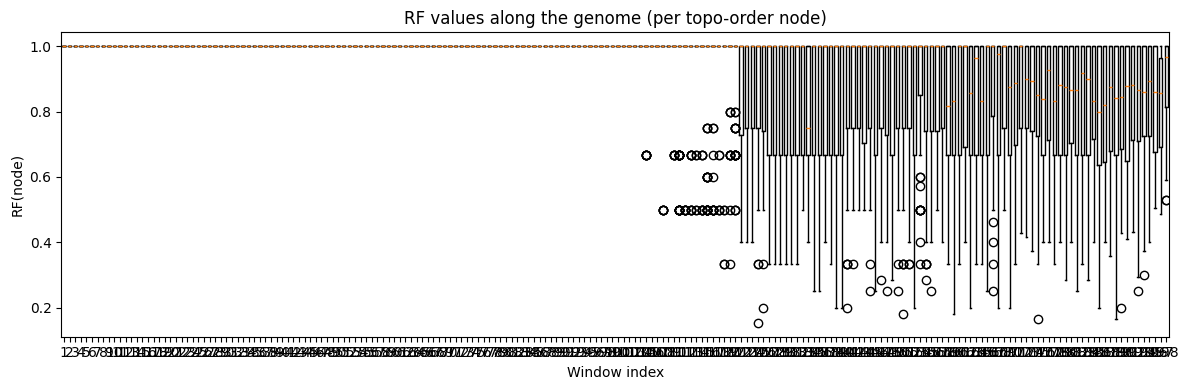

In [18]:
topo_order_value=[]
n=100
for i in range(n):
    pos = int(seq_length / n * i)
    tree1=true_arg.at(pos)
    tree2=inferred_arg.at(pos)
    rf_nrs=branch_rf(tree1,tree2)
    l=[]
    for nd in tree1.nodes(order="timeasc"):
        l.append(rf_nrs[nd])
    topo_order_value.append(l)
topo_order_value=np.array(topo_order_value)
plt.figure(figsize=(12,4))
plt.boxplot(
    topo_order_value[:,:-1],     
    widths=0.6
)

plt.xlabel("Window index")
plt.ylabel("RF(node)")
plt.title("RF values along the genome (per topo-order node)")
plt.tight_layout()
plt.show()

/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


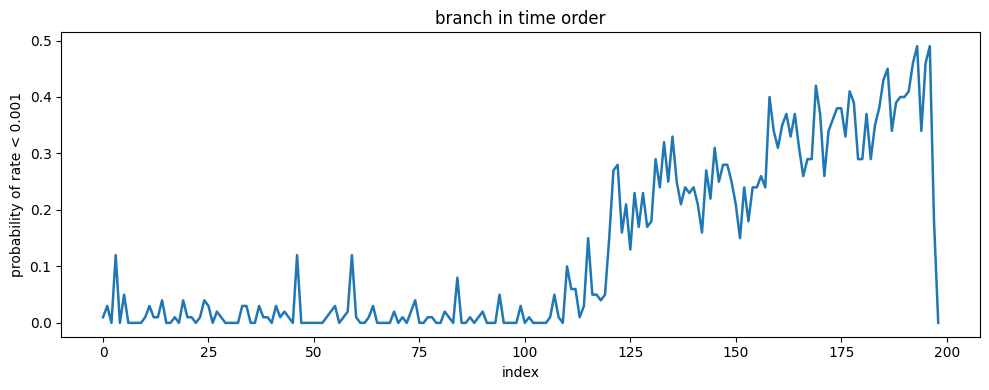

In [26]:
topo_order_value=[]
n=100
seq_length=true_arg.sequence_length
for i in range(n):
    pos = float(seq_length / n * i)
    tree1=true_arg.at(pos)
    tree2=inferred_arg.at(pos)
    if (tree1.num_roots>1 or tree2.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(tree1, tree2)
    l=[]
    for nd in tree1.nodes(order="timeasc"):
        l.append((node_to_rate[nd] is not None) and (node_to_rate[nd] < 0.001))
    topo_order_value.append(l)
topo_order_value=np.array(topo_order_value)

arr = np.array(topo_order_value, dtype=float)   

means = np.nanmean(arr, axis=0)  

x = np.arange(len(means))

plt.figure(figsize=(10,4))
plt.plot(x, means, linewidth=1.8)
plt.xlabel("index")
plt.ylabel("probability of rate < 0.001")
plt.title("branch in time order")
plt.tight_layout()
plt.show()

In [86]:
topo_order_value

array([[2.933203045743651, 3.562541502161662, 5.846612370059037, ...,
        1.3009660195543568e-07, None, None],
       [3.2880571202575224, 3.73306110453691, 3.7272966335404387, ...,
        -9.699723401567137e-09, None, None],
       [2.9112830341150193, 3.58321387272412, 5.537858801516126, ...,
        None, 1.437509738981952, None],
       ...,
       [3.082842520924204, 2.9513675276310822, 5.7458365113120236, ...,
        4.476351565037296e-06, 2.125995615005908, None],
       [0.9798464444822299, 3.033390994131713, 6.978273352275773, ...,
        None, 1.0048776123261145, None],
       [1.02561562718218, 3.2966135766134363, 4.8431392286454304, ...,
        0.38620032310249575, None, None]], shape=(100, 199), dtype=object)

/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


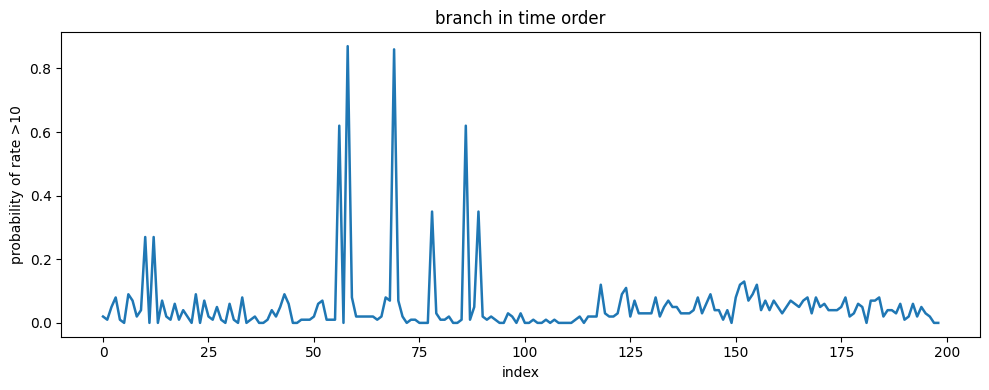

In [27]:
topo_order_value=[]
seq_length=true_arg.sequence_length
n=100
for i in range(n):
    pos = float(seq_length / n * i)
    tree1=true_arg.at(pos)
    tree2=inferred_arg.at(pos)
    if (tree1.num_roots>1 or tree2.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(tree1, tree2)
    l=[]
    for nd in tree1.nodes(order="timeasc"):
        l.append((node_to_rate[nd] is not None) and (node_to_rate[nd] >10))
    topo_order_value.append(l)
topo_order_value=np.array(topo_order_value)

arr = np.array(topo_order_value, dtype=float)   

means = np.nanmean(arr, axis=0)  

x = np.arange(len(means))

plt.figure(figsize=(10,4))
plt.plot(x, means, linewidth=1.8)
plt.xlabel("index")
plt.ylabel("probability of rate >10")
plt.title("branch in time order")
plt.tight_layout()
plt.show()

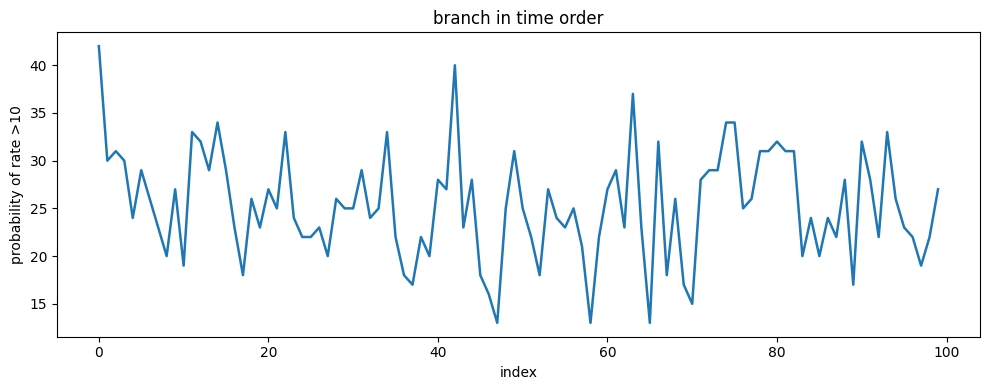

mean= 25.29


In [26]:
true_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/Ne2e+04_r1e-08_100_1e+06_0.trees")
inferred_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/singer_inferred/Ne2e+04_r1e-08_100_1e+06_49.trees")
num_zero=[]
seq_length=true_arg.sequence_length
n=100
for i in range(n):
    pos = float(seq_length / n * i)
    tree1=true_arg.at(pos)
    tree2=inferred_arg.at(pos)
    if (tree1.num_roots>1 or tree2.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(tree1, tree2)
    count = sum(abs(x) < 0.001 for x in rates)

    num_zero.append(count)
 

x = np.arange(len(num_zero))

plt.figure(figsize=(10,4))
plt.plot(x, num_zero, linewidth=1.8)
plt.xlabel("index")
plt.ylabel("probability of rate >10")
plt.title("branch in time order")
plt.tight_layout()
plt.show()
print("mean=",np.mean(num_zero))

/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


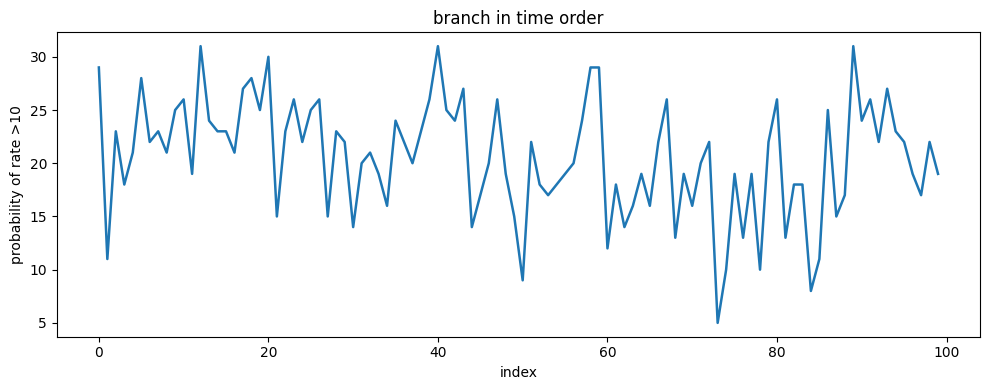

mean= 20.57


In [24]:
true_arg2=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r2e-08_100_1e+06/0/Ne2e+04_r2e-08_100_1e+06_0.trees")
inferred_arg2=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r2e-08_100_1e+06/0/singer_inferred/Ne2e+04_r2e-08_100_1e+06_49.trees")
num_zero=[]
seq_length=true_arg2.sequence_length
n=100
for i in range(n):
    pos = float(seq_length / n * i)
    tree1=true_arg2.at(pos)
    tree2=inferred_arg2.at(pos)
    if (tree1.num_roots>1 or tree2.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(tree1, tree2)
    count = sum(abs(x) < 0.001 for x in rates)

    num_zero.append(count)
 

x = np.arange(len(num_zero))

plt.figure(figsize=(10,4))
plt.plot(x, num_zero, linewidth=1.8)
plt.xlabel("index")
plt.ylabel("probability of rate >10")
plt.title("branch in time order")
plt.tight_layout()
plt.show()
print("mean=",np.mean(num_zero))

/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


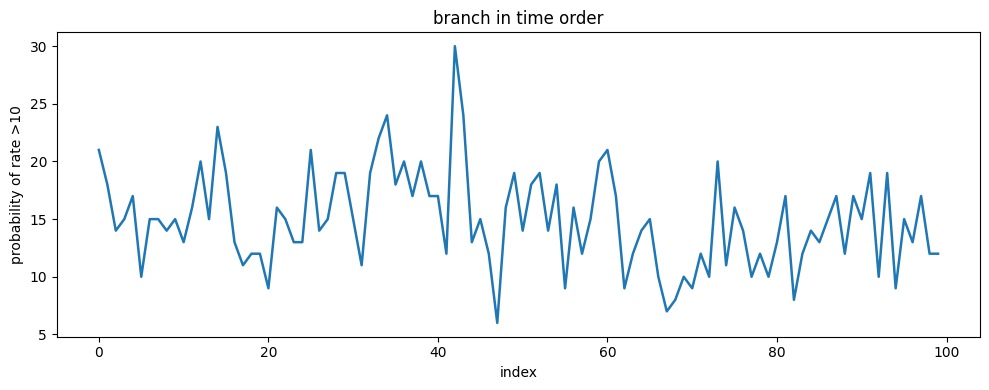

mean= 14.9


In [ ]:
true_arg5=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r5e-08_100_1e+06/0/Ne2e+04_r5e-08_100_1e+06_0.trees")
inferred_arg5=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r5e-08_100_1e+06/0/singer_inferred/Ne2e+04_r5e-08_100_1e+06_49.trees")
num_zero=[]
seq_length=true_arg5.sequence_length
n=10
for i in range(n):
    pos = float(seq_length / n * i)
    tree1=true_arg5.at(pos)
    tree2=inferred_arg5.at(pos)
    if (tree1.num_roots>1 or tree2.num_roots>1):
        print("trees have multiple roots")
        continue
    else:
        rates,node_to_rate = compare_trees_TCMM(tree1, tree2)
    count = sum(abs(x) < 0.001 for x in rates)

    num_zero.append(count)
 

x = np.arange(len(num_zero))

plt.figure(figsize=(10,4))
plt.plot(x, num_zero, linewidth=1.8)
plt.xlabel("index")
plt.ylabel("probability of rate >10")
plt.title("branch in time order")
plt.tight_layout()
plt.show()
print("mean=",np.mean(num_zero))

In [ ]:
#get all rates for all possible scenarios

all_rates={}

root = "/Users/jinminli/research/tree_distance/simulations/small_diff_rate"

r_values = ["1e-08", "2e-08", "5e-08", "5e-09"]

for r in r_values:
    folder = f"Ne2e+04_r{r}_100_1e+06"

    for rep in range(100):
        rep_dir = os.path.join(root, folder, str(rep))

        true_path = os.path.join(
            rep_dir,
            f"Ne2e+04_r{r}_100_1e+06_{rep}.trees"
        )

        inferred_path = os.path.join(
            rep_dir,
            "singer_inferred",
            f"Ne2e+04_r{r}_100_1e+06_{rep}.trees"
        )

        if os.path.exists(true_path) and os.path.exists(inferred_path):
            true_ts = tskit.load(true_path)
            inferred_ts = tskit.load(inferred_path)

            print("Loaded:", true_path, inferred_path)

        else:
            print("Missing file:", true_path, inferred_path)
            continue

        all_rates[[r,rep]]

In [77]:
import os
import tskit
import numpy as np
import matplotlib.pyplot as plt

root = "/Users/jinminli/research/tree_distance/simulations/small_diff_rate"

r_values = ["1e-08", "2e-08", "5e-08", "5e-09"]
n_positions = 3   


all_rates = {}
all_nodes_to_rates={}

for r in r_values:
    scenario = f"Ne2e+04_r{r}_100_1e+06"

    for rep in range(100):
        rep_dir = os.path.join(root, scenario, str(rep))

        true_path = os.path.join(rep_dir, f"{scenario}_{rep}.trees")

        inferred_path = os.path.join(rep_dir, "singer_inferred",
                                     f"{scenario}_49.trees")

        if not (os.path.exists(true_path) and os.path.exists(inferred_path)):
            continue

        true_ts = tskit.load(true_path)
        inferred_ts = tskit.load(inferred_path)

        L = true_ts.sequence_length
        bin_width = (L-1) / (n_positions-1)
        rates_list = []
        nr_list = []

        for i in range(n_positions):
            pos = i* bin_width

            tree1 = true_ts.at(pos)
            tree2 = inferred_ts.at(pos)

            # skip invalid trees
            if tree1.num_roots > 1 or tree2.num_roots > 1:
                rates_list.append(np.nan)
                continue

            rates, node_to_rate = compare_trees_TCMM(tree1, tree2)
            # count = sum(abs(x) < 0.001 for x in rates)

            rates_list.append(rates)
            nr_list.append([node_to_rate,pos])

        all_rates[(r, rep)] = np.array(rates_list)
        all_nodes_to_rates[(r,rep)]=nr_list


/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: divide by zero encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: overflow encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)
/Users/jinminli/research/tree_distance/scr/multiple_tree_matching.py:354: RuntimeWarning: invalid value encountered in matmul
  initial_obj = np.fabs((w_0.T @ AtA @ w_0) - 2 * Atd.T @ w_0)


In [55]:
all_rates[("1e-08",0)]

array([[ 2.16608151e+00,  3.47491028e+00,  8.51945684e+00,
         4.23636721e+01,  4.23636721e+01,  8.17721167e+00,
        -3.85235927e-06, -1.78646910e-06,  9.11539262e-01,
         5.84661237e+00,  5.84661237e+00,  5.97046803e-01,
         4.30390979e-01,  4.25389116e-01,  2.41842027e+01,
         2.00036000e+00,  1.07429920e+00,  1.07429920e+00,
         2.99846155e+00, -1.12839977e-07,  5.76867096e-01,
         5.26079786e+01,  5.22330108e+01,  8.56345881e-01,
         2.47746947e-01,  6.08906844e-03,  6.08906844e-03,
         5.03857107e-01,  3.34401757e+00,  2.00685338e+00,
         3.69409101e+00,  4.22672851e+00,  4.25949354e+00,
        -2.93185726e-05,  1.85045137e+00,  3.08697619e+00,
        -9.92703982e-08, -7.82793866e-07,  3.12880976e+00,
         7.35340951e-01,  8.47806913e-01,  8.60754205e-01,
         2.59352471e-01,  3.70708016e+00, -7.77475196e-07,
         2.28925015e+00,  3.84024503e-01,  1.40387309e+00,
         1.40387309e+00,  2.93305022e-01,  8.41270159e+0

In [64]:
all_rates[("1e-08",0)][0]

array([ 2.16608151e+00,  3.47491028e+00,  8.51945684e+00,  4.23636721e+01,
        4.23636721e+01,  8.17721167e+00, -3.85235927e-06, -1.78646910e-06,
        9.11539262e-01,  5.84661237e+00,  5.84661237e+00,  5.97046803e-01,
        4.30390979e-01,  4.25389116e-01,  2.41842027e+01,  2.00036000e+00,
        1.07429920e+00,  1.07429920e+00,  2.99846155e+00, -1.12839977e-07,
        5.76867096e-01,  5.26079786e+01,  5.22330108e+01,  8.56345881e-01,
        2.47746947e-01,  6.08906844e-03,  6.08906844e-03,  5.03857107e-01,
        3.34401757e+00,  2.00685338e+00,  3.69409101e+00,  4.22672851e+00,
        4.25949354e+00, -2.93185726e-05,  1.85045137e+00,  3.08697619e+00,
       -9.92703982e-08, -7.82793866e-07,  3.12880976e+00,  7.35340951e-01,
        8.47806913e-01,  8.60754205e-01,  2.59352471e-01,  3.70708016e+00,
       -7.77475196e-07,  2.28925015e+00,  3.84024503e-01,  1.40387309e+00,
        1.40387309e+00,  2.93305022e-01,  8.41270159e+01, -9.52678900e-07,
        9.70842693e-01,  

In [ ]:
scenario_stats = {}

for r in r_values:
    arr = []

    for rep in range(100):
        local_arr=[]
        key = (r, rep)
        if key in all_rates:
            for i in range(n_positions):
                local_arr.append(sum(abs(x) < 0.001 for x in all_rates[key][i]))
            arr.append(local_arr)

    arr = np.array(arr)     # shape (#replicates, n_positions)

    mean = np.nanmean(arr, axis=0)
    q10 = np.nanquantile(arr, 0.10, axis=0)
    q90 = np.nanquantile(arr, 0.90, axis=0)

    scenario_stats[r] = (mean, q10, q90)


('1e-08', 0)
('1e-08', 2)
('1e-08', 3)
('1e-08', 5)
('1e-08', 6)
('1e-08', 7)
('1e-08', 8)
('1e-08', 9)
('1e-08', 10)
('1e-08', 13)
('1e-08', 14)
('1e-08', 15)
('1e-08', 17)
('1e-08', 19)
('1e-08', 20)
('1e-08', 22)
('1e-08', 23)
('1e-08', 24)
('1e-08', 25)
('1e-08', 26)
('1e-08', 27)
('1e-08', 28)
('1e-08', 29)
('1e-08', 30)
('1e-08', 32)
('1e-08', 33)
('1e-08', 34)
('1e-08', 35)
('1e-08', 36)
('1e-08', 37)
('1e-08', 38)
('1e-08', 39)
('1e-08', 40)
('1e-08', 41)
('1e-08', 42)
('1e-08', 43)
('1e-08', 44)
('1e-08', 45)
('1e-08', 46)
('1e-08', 47)
('1e-08', 48)
('1e-08', 49)
('1e-08', 50)
('1e-08', 51)
('1e-08', 52)
('1e-08', 53)
('1e-08', 54)
('1e-08', 55)
('1e-08', 56)
('1e-08', 58)
('1e-08', 59)
('1e-08', 60)
('1e-08', 62)
('1e-08', 64)
('1e-08', 65)
('1e-08', 66)
('1e-08', 68)
('1e-08', 69)
('1e-08', 70)
('1e-08', 72)
('1e-08', 73)
('1e-08', 74)
('1e-08', 75)
('1e-08', 76)
('1e-08', 77)
('1e-08', 78)
('1e-08', 80)
('1e-08', 81)
('1e-08', 82)
('1e-08', 83)
('1e-08', 84)
('1e-08', 85)


In [75]:
arr

array([[39, 25, 32],
       [32, 29, 38],
       [40, 34, 34],
       [43, 16, 38],
       [46, 33, 33],
       [35, 38, 44],
       [37, 30, 37],
       [39, 31, 29],
       [32, 20, 34],
       [46, 30, 46],
       [35, 21, 29],
       [36, 30, 31],
       [42, 32, 38],
       [44, 32, 33],
       [31, 24, 29],
       [63, 70, 77],
       [42, 40, 37],
       [45, 31, 33],
       [40, 37, 39],
       [39, 25, 37],
       [31, 27, 37],
       [33, 29, 34],
       [41, 38, 43],
       [46, 25, 46],
       [30, 36, 35],
       [40, 32, 40],
       [33, 35, 36],
       [52, 30, 20],
       [26, 30, 42],
       [40, 32, 23],
       [40, 26, 37],
       [70, 81, 75],
       [34, 26, 35],
       [41, 30, 33],
       [30, 24, 39],
       [39, 33, 38],
       [48, 31, 36],
       [31, 32, 39],
       [34, 26, 34],
       [40, 34, 41],
       [75, 69, 76],
       [81, 72, 69],
       [42, 22, 48],
       [42, 28, 37],
       [51, 32, 41],
       [41, 28, 48],
       [41, 25, 48],
       [32, 2

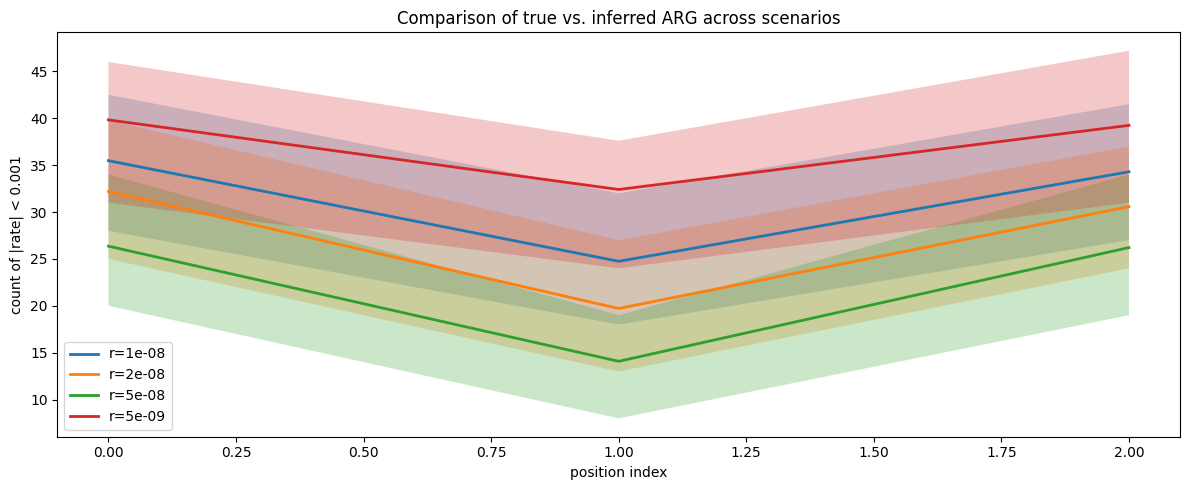

In [76]:
plt.figure(figsize=(12, 5))
x = np.arange(n_positions)

for r in r_values:
    mean, q10, q90 = scenario_stats[r]

    plt.plot(x, mean, label=f"r={r}", linewidth=2)
    plt.fill_between(x, q10, q90, alpha=0.25)

plt.xlabel("position index")
plt.ylabel("count of |rate| < 0.001")
plt.title("Comparison of true vs. inferred ARG across scenarios")
plt.legend()
plt.tight_layout()
plt.show()
